# Отток клиентов банка «Метанпром»: портрет уходящего клиента

**Задача.** По данным 10 000 клиентов регионального банка найти признаки, которые связаны с уходом клиента (`churn`), и описать сегменты с повышенным риском оттока — чтобы банк понимал, на кого направлять удерживающие предложения.

**Данные** — два датасета, связанные по `userid`:

`bank_information.csv` — использование услуг банка:
- `userid` — идентификатор клиента;
- `score` — баллы кредитного скоринга;
- `Objects` — количество объектов в собственности;
- `Balance` — баланс на счёте;
- `Products` — количество продуктов банка у клиента;
- `CreditCard` — есть ли кредитная карта;
- `Loyalty` — активный клиент / участник программы лояльности;
- `estimated_salary` — оценочный доход;
- `Churn` — ушёл ли клиент из банка (целевой признак).

`clients_information.csv` — персональные данные:
- `userid`, `LastName`, `FirstName`, `City` (город обращения), `Gender`, `Age`.

**План**
1. Загрузка и первичный осмотр данных.
2. Предобработка: названия столбцов, типы, пропуски, дубликаты, объединение таблиц.
3. Исследовательский анализ: распределения признаков, корреляция с оттоком, сравнение сегментов.
4. Выводы и рекомендации.

## 1. Загрузка и первичный осмотр данных

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik  # регистрирует метод DataFrame.phik_matrix()

In [ ]:
bank_df = pd.read_csv('https://code.s3.yandex.net/datasets/bank_information.csv')
clients_df = pd.read_csv('https://code.s3.yandex.net/datasets/clients_information.csv')

In [ ]:
bank_df.head()

,userid,score,Objects,Balance,Products,CreditCard,Loyalty,estimated_salary,Churn
0,15677338,619,2,NaN,1,1,1,101348.88,1
1,15690047,608,1,83807.86,1,0,1,112542.58,0
2,15662040,502,8,159660.80,3,1,0,113931.57,1
3,15744090,699,1,NaN,2,0,0,93826.63,0
4,15780624,850,2,125510.82,1,1,1,79084.10,0


In [ ]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            10000 non-null  int64  
 1   score             10000 non-null  int64  
 2   Objects           10000 non-null  int64  
 3   Balance           6383 non-null   float64
 4   Products          10000 non-null  int64  
 5   CreditCard        10000 non-null  int64  
 6   Loyalty           10000 non-null  int64  
 7   estimated_salary  10000 non-null  float64
 8   Churn             10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.3 KB


`bank_information`: 10 000 строк, 9 столбцов, все признаки числовые.

- Названия столбцов в разном стиле — приведу к snake_case.
- `Objects`, `Products`, `CreditCard`, `Loyalty`, `Churn` — небольшие целые числа или бинарные флаги 0/1, разрядность типов можно понизить.
- Пропуски только в `Balance` (~36%) — нужно разобраться, откуда они. В остальных столбцах проверю, нет ли значений-заглушек.

In [ ]:
clients_df.head()

,userid,LastName,FirstName,Age,Gender,City
0,15677338,Лапина,Евпраксия,42,Ж,Ярославль
1,15690047,Александрова,Акулина,41,Ж,Рыбинск
2,15662040,Лаврентьева,Анна,42,Ж,Ярославль
3,15744090,Никитина,Олимпиада,39,Ж,Ярославль
4,15780624,Некрасова,Майя,43,Ж,Рыбинск


In [ ]:
clients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userid     10000 non-null  int64 
 1   LastName   10000 non-null  object
 2   FirstName  10000 non-null  object
 3   Age        10000 non-null  int64 
 4   Gender     10000 non-null  object
 5   City       10000 non-null  object
dtypes: int64(2), object(4)
memory usage: 468.9+ KB


`clients_information`: 10 000 строк, 6 столбцов, явных пропусков нет. Названия столбцов тоже нужно привести к snake_case, `Age` — перевести в меньший целочисленный тип.

В целом данные выглядят аккуратно, основная работа — пропуски в балансе.

## 2. Предобработка данных

### 2.1. Названия столбцов

Пишу функцию, которая переводит CamelCase в snake_case (`CreditCard` → `credit_card`), и применяю её к обеим таблицам.

In [ ]:
def col_to_snake_case(df):
    """Переводит названия столбцов датафрейма из CamelCase в snake_case."""
    for col in df.columns:
        new_col = col[0].lower() + col[1:]
        for i, ch in enumerate(new_col):
            if ch.isupper():
                new_col = new_col[:i] + '_' + ch.lower() + new_col[i + 1:]
        df = df.rename(columns={col: new_col})
    return df

In [ ]:
bank_df = col_to_snake_case(bank_df)
clients_df = col_to_snake_case(clients_df)

print(bank_df.columns.tolist())
print(clients_df.columns.tolist())

['userid', 'score', 'objects', 'balance', 'products', 'credit_card', 'loyalty', 'estimated_salary', 'churn']
['userid', 'last_name', 'first_name', 'age', 'gender', 'city']


### 2.2. Типы данных

Понижаю разрядность целочисленных столбцов: флаги 0/1 и небольшие счётчики помещаются в `int8`/`int16`.

In [ ]:
int_cols = ['score', 'objects', 'products', 'credit_card', 'loyalty', 'churn']
for column in int_cols:
    bank_df[column] = pd.to_numeric(bank_df[column], downcast='integer')

clients_df['age'] = pd.to_numeric(clients_df['age'], downcast='integer')

In [ ]:
bank_df.dtypes

userid                int64
score                 int16
objects                int8
balance             float64
products               int8
credit_card            int8
loyalty                int8
estimated_salary    float64
churn                  int8
dtype: object

In [ ]:
clients_df.dtypes

userid         int64
last_name     object
first_name    object
age             int8
gender        object
city          object
dtype: object

### 2.3. Пропуски

Считаю абсолютное и относительное количество пропусков в `bank_df`.

In [ ]:
bank_df.isna().sum()

userid                 0
score                  0
objects                0
balance             3617
products               0
credit_card            0
loyalty                0
estimated_salary       0
churn                  0
dtype: int64

In [ ]:
bank_df.isna().mean()

userid              0.0000
score               0.0000
objects             0.0000
balance             0.3617
products            0.0000
credit_card         0.0000
loyalty             0.0000
estimated_salary    0.0000
churn               0.0000
dtype: float64

В `balance` 3 617 пропусков — 36% строк. Удалять столько данных нельзя, заполнять средним — тоже: исказится распределение. Сначала проверю, случайны ли пропуски. Гипотезы:

- **Клиент не пользуется продуктами со счётом** (например, только страховкой). Данных о типе продукта нет, напрямую не проверить — это был бы MNAR.
- **Технический сбой при выгрузке** — тогда пропуски не связаны с другими признаками (MCAR).
- **Клиент закрыл счёт и ушёл** — тогда пропуски связаны с `churn` и `products` (MAR). Это можно проверить.

Добавляю флаг `is_balance` (1 — баланс указан, 0 — пропуск) и сравниваю две группы.

In [ ]:
bank_df['is_balance'] = bank_df['balance'].notna().astype('int8')

Для дискретных `objects` и `products` беру медиану, для непрерывных `score` и `estimated_salary` — среднее, для бинарных флагов — среднее, то есть долю единиц.

In [ ]:
bank_df.groupby('is_balance').agg({
    'score': 'mean',
    'objects': 'median',
    'products': 'median',
    'credit_card': 'mean',
    'loyalty': 'mean',
    'churn': 'mean',
    'estimated_salary': 'mean'
})

,score,objects,products,credit_card,loyalty,churn,estimated_salary
is_balance,,,,,,,
0,649.452861,5.0,2.0,0.716616,0.517832,0.138236,98983.559549
1,651.138493,5.0,1.0,0.699201,0.513552,0.240796,100717.352956


- У клиентов без баланса медиана — 2 продукта, у клиентов с балансом — 1.
- Отток среди клиентов с указанным балансом заметно выше: ~24% против ~14%.
- По скорингу, доходу, недвижимости и кредиткам группы почти не отличаются.

Значит, пропуски не случайны: они связаны с набором продуктов клиента, а гипотеза «ушёл и закрыл счёт» не подтверждается — ушедших среди клиентов без баланса как раз меньше. Скорее всего, баланс не заполняется для определённых продуктов. Пропуски оставляю как есть, а флаг `is_balance` использую в анализе как отдельный признак.

Проверяю, нет ли в дискретных столбцах значений-заглушек (например, -1 или 999):

In [ ]:
for column in ['objects', 'products', 'credit_card', 'loyalty', 'churn']:
    print(f'{column}: {sorted(bank_df[column].unique())}')

objects: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
products: [1, 2, 3, 4]
credit_card: [0, 1]
loyalty: [0, 1]
churn: [0, 1]


Заглушек нет, все значения в допустимых диапазонах.

### 2.4. Дубликаты

In [ ]:
bank_df.duplicated().sum()

0

In [ ]:
clients_df.duplicated().sum()

0

Полных дубликатов нет. Проверяю уникальность `userid` — одна строка должна соответствовать одному клиенту:

In [ ]:
bank_df.duplicated(subset='userid').sum()

0

In [ ]:
clients_df.duplicated(subset='userid').sum()

0

Повторов `userid` нет. Проверяю написание категориальных значений:

In [ ]:
for column in ['gender', 'city']:
    print(f'{column}: {sorted(clients_df[column].unique())}')

gender: ['Ж', 'М']
city: ['Ростов Великий', 'Рыбинск', 'Ярославль']


Опечаток и неявных дубликатов в категориях нет.

### 2.5. Итоги предобработки

- Названия столбцов приведены к snake_case, разрядность целочисленных типов понижена.
- Пропуски есть только в `balance` (36%). Они связаны с количеством продуктов клиента, поэтому оставлены, а их наличие вынесено в признак `is_balance`.
- Дубликатов и некорректных значений нет.

### 2.6. Объединение таблиц

Соединяю таблицы по `userid` через inner join, чтобы в анализ попали только клиенты с полными данными.

In [ ]:
df = bank_df.merge(clients_df, on='userid')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            10000 non-null  int64  
 1   score             10000 non-null  int16  
 2   objects           10000 non-null  int8   
 3   balance           6383 non-null   float64
 4   products          10000 non-null  int8   
 5   credit_card       10000 non-null  int8   
 6   loyalty           10000 non-null  int8   
 7   estimated_salary  10000 non-null  float64
 8   churn             10000 non-null  int8   
 9   is_balance        10000 non-null  int64  
 10  last_name         10000 non-null  object 
 11  first_name        10000 non-null  object 
 12  age               10000 non-null  int8   
 13  gender            10000 non-null  object 
 14  city              10000 non-null  object 
dtypes: float64(2), int16(1), int64(2), int8(6), object(4)
memory usage: 781.2+ KB


После объединения сохранились все 10 000 клиентов.

## 3. Исследовательский анализ данных

### 3.1. Дискретные признаки: объекты собственности и продукты

In [ ]:
df['objects'].value_counts().sort_index()

11 значений от 0 до 10. Группы 1–9 примерно одинаковые (~1 000 клиентов), а 0 и 10 объектов — вдвое меньше. Это нужно учитывать, когда сравниваю доли по группам.

In [ ]:
df['products'].value_counts().sort_index()

Почти все клиенты пользуются одним (5 084) или двумя (4 590) продуктами. Три и четыре продукта — всего 326 человек, выводы по этим группам будут ненадёжными.

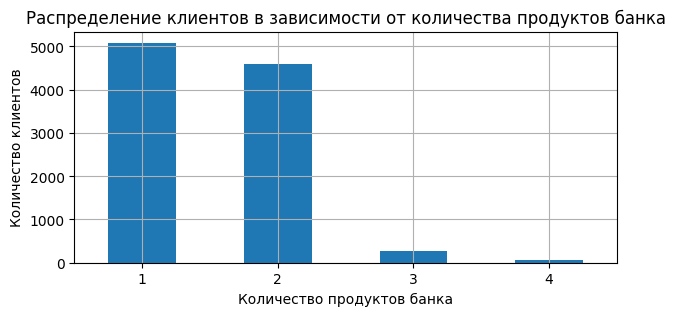

In [ ]:
plt.figure(figsize=(7, 3))
df['products'].value_counts().sort_index().plot(
    kind='bar', rot=0, legend=False,
    title='Распределение клиентов по количеству продуктов банка'
)
plt.xlabel('Количество продуктов банка')
plt.ylabel('Количество клиентов')
plt.grid()
plt.show()

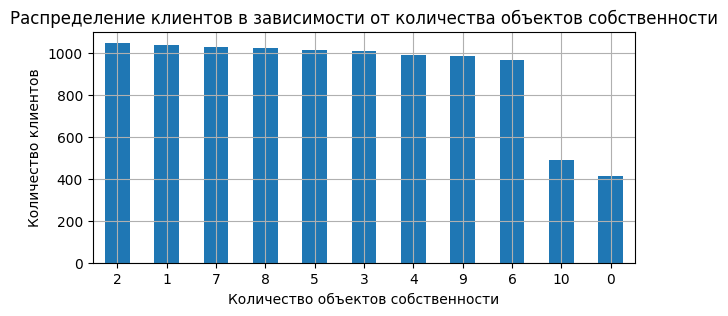

In [ ]:
plt.figure(figsize=(7, 3))
df['objects'].value_counts().sort_index().plot(
    kind='bar', rot=0, legend=False,
    title='Распределение клиентов по количеству объектов собственности'
)
plt.xlabel('Количество объектов собственности')
plt.ylabel('Количество клиентов')
plt.grid()
plt.show()

### 3.2. Непрерывные признаки

**Баланс**

In [ ]:
df['balance'].describe()

Статистические показатели столбца balance:


count      6383.000000
mean     119827.493793
std       30095.056462
min        3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
max      250898.090000
Name: balance, dtype: float64

Среднее (~119 800) и медиана (~119 840) почти совпадают — распределение близко к симметричному. Стандартное отклонение ~30 000, разброс от ~3 800 до ~250 900.

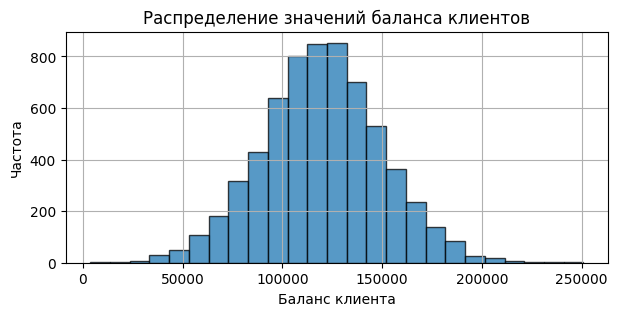

In [ ]:
plt.figure(figsize=(7, 3))
df['balance'].plot(kind='hist', bins=25, alpha=0.75, edgecolor='black')
plt.title('Распределение баланса клиентов')
plt.xlabel('Баланс клиента')
plt.ylabel('Частота')
plt.grid()
plt.show()

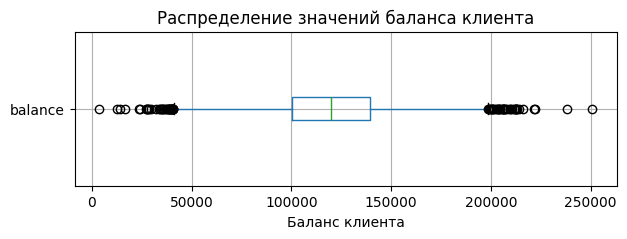

In [ ]:
plt.figure(figsize=(7, 2))
df.boxplot(column='balance', vert=False)
plt.title('Диаграмма размаха: баланс клиента')
plt.xlabel('Баланс клиента')
plt.show()

Распределение близко к нормальному, с «хвостами» с обеих сторон. Формально крайние значения — выбросы, но выглядят правдоподобно для банковского счёта, поэтому оставляю их.

**Кредитный скоринг**

In [ ]:
df['score'].describe()

Статистические показатели столбца score:


count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: score, dtype: float64

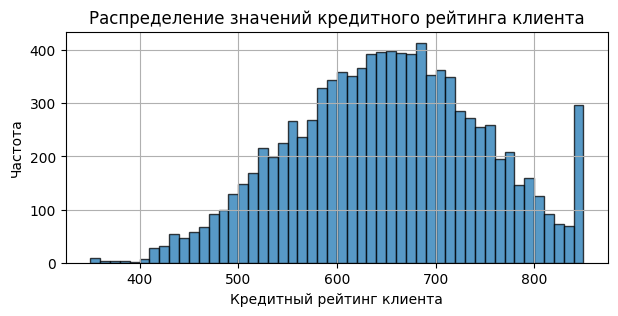

In [ ]:
plt.figure(figsize=(7, 3))
df['score'].plot(kind='hist', bins=50, alpha=0.75, edgecolor='black')
plt.title('Распределение кредитного скоринга')
plt.xlabel('Кредитный скоринг')
plt.ylabel('Частота')
plt.grid()
plt.show()

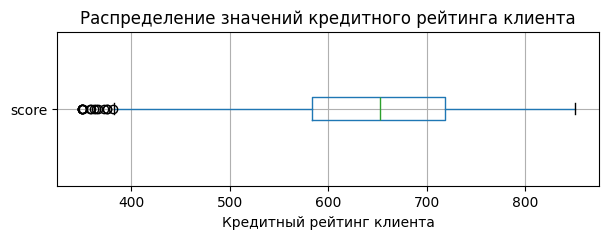

In [ ]:
plt.figure(figsize=(7, 2))
df.boxplot(column='score', vert=False)
plt.title('Диаграмма размаха: кредитный скоринг')
plt.xlabel('Кредитный скоринг')
plt.show()

Распределение близко к нормальному, но у значения 850 резкий пик. Две версии:
- 850 — заглушка для клиентов без кредитной истории;
- 850 — потолок шкалы, и всем с более высоким рейтингом присваивается максимум.

Низкие значения похожи на выбросы, но реалистичны для клиентов с просрочками — оставляю. Проверяю пик:

In [ ]:
df.loc[df['score'] >= 840, 'score'].value_counts()

Значение 850 встречается у 233 клиентов, соседние 840–849 — по 2–12 раз. Пик явно искусственный, скорее всего это потолок шкалы. На анализ оттока он почти не влияет (связь скоринга с оттоком слабая, см. ниже), поэтому значения не трогаю.

**Оценочный доход**

In [ ]:
df['estimated_salary'].describe()

Статистические показатели столбца estimated_salary:


count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: estimated_salary, dtype: float64

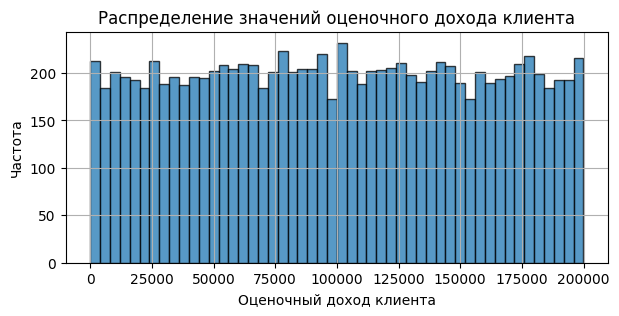

In [ ]:
plt.figure(figsize=(7, 3))
df['estimated_salary'].plot(kind='hist', bins=50, alpha=0.75, edgecolor='black')
plt.title('Распределение оценочного дохода')
plt.xlabel('Оценочный доход')
plt.ylabel('Частота')
plt.grid()
plt.show()

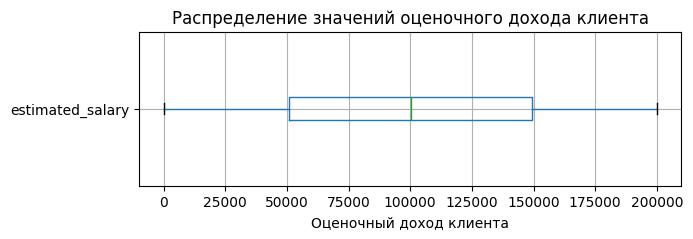

In [ ]:
plt.figure(figsize=(7, 2))
df.boxplot(column='estimated_salary', vert=False)
plt.title('Диаграмма размаха: оценочный доход')
plt.xlabel('Оценочный доход')
plt.show()

Доход распределён практически равномерно от 0 до 200 000 — для реальных зарплат это нетипично, похоже на синтетическую или сильно обработанную оценку. При интерпретации связи дохода с оттоком это стоит учитывать.

**Возраст**

In [ ]:
df['age'].describe()

Статистические показатели столбца age:


count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: age, dtype: float64

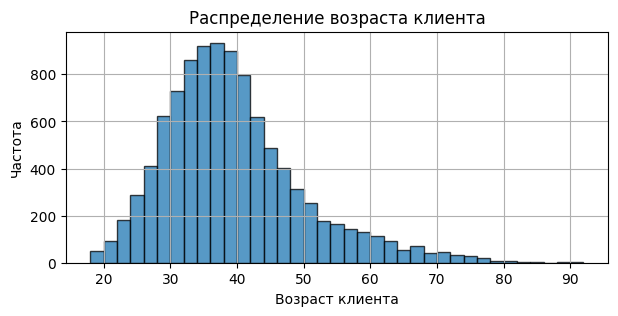

In [ ]:
plt.figure(figsize=(7, 3))
df['age'].plot(kind='hist', bins=37, alpha=0.75, edgecolor='black')
plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.grid()
plt.show()

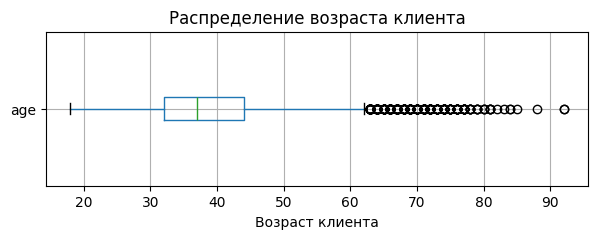

In [ ]:
plt.figure(figsize=(7, 2))
df.boxplot(column='age', vert=False)
plt.title('Диаграмма размаха: возраст')
plt.xlabel('Возраст')
plt.show()

Возраст от 18 до 92 лет, среднее 39, медиана 37 — распределение скошено вправо. Значения старше ~62 лет формально выбросы, но это реальный сегмент пенсионеров, поэтому оставляю их в анализе.

### 3.3. Бинарные и категориальные признаки

In [ ]:
for column in ['credit_card', 'loyalty', 'churn']:
    print(df[column].value_counts(normalize=True).round(3), end='\n\n')

credit_card
1    0.706
0    0.294
Name: proportion, dtype: float64

loyalty
1    0.515
0    0.485
Name: proportion, dtype: float64

churn
0    0.796
1    0.204
Name: proportion, dtype: float64



- Из банка ушли ~20% клиентов.
- Кредитная карта есть у ~71%.
- Активных клиентов / участников программы лояльности — ~52%.

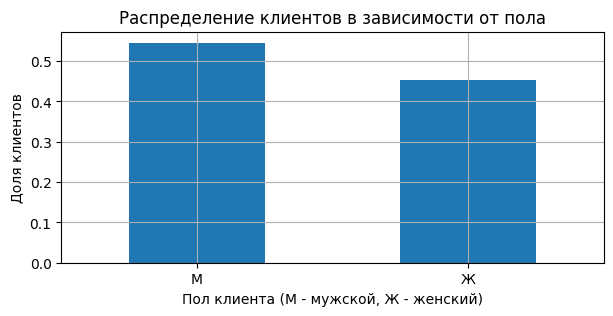

In [ ]:
plt.figure(figsize=(7, 3))
df['gender'].value_counts(normalize=True).plot(
    kind='bar', rot=0, legend=False,
    title='Распределение клиентов по полу'
)
plt.xlabel('Пол (М — мужской, Ж — женский)')
plt.ylabel('Доля клиентов')
plt.grid()
plt.show()

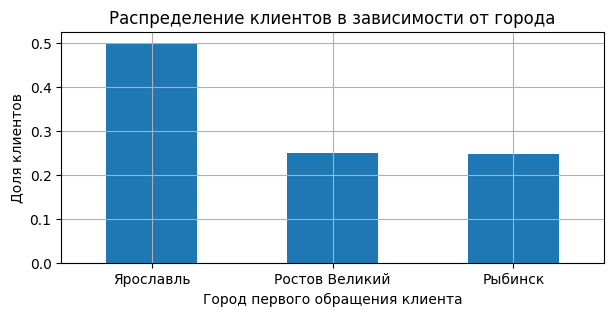

In [ ]:
plt.figure(figsize=(7, 3))
df['city'].value_counts(normalize=True).plot(
    kind='bar', rot=0, legend=False,
    title='Распределение клиентов по городам'
)
plt.xlabel('Город обращения')
plt.ylabel('Доля клиентов')
plt.grid()
plt.show()

Чуть больше половины клиентов (~55%) — женщины. Половина клиентов из Ярославля, остальные поровну из Ростова Великого и Рыбинска.

In [ ]:
df['is_balance'].value_counts(normalize=True)

Баланс не указан у 36% клиентов.

**Промежуточный итог — портрет клиента банка**
- 10 000 клиентов из трёх городов: половина — Ярославль, остальные поровну Ростов Великий и Рыбинск.
- ~55% — женщины, средний возраст — 39 лет.
- Обычно 1–2 продукта банка. Средний баланс ~120 тыс. руб., у 36% клиентов баланс не указан.
- ~71% клиентов имеют кредитную карту, ~52% — активные.
- Отток — ~20%.

### 3.4. Корреляция признаков с оттоком

Признаки разнотипные: непрерывные (баланс, доход), дискретные, бинарные и категориальные (город, пол). Обычный коэффициент Пирсона здесь не подходит, поэтому использую `phi_k` — он работает с любой комбинацией типов и ловит нелинейные связи.

In [ ]:
cols = ['objects', 'products', 'balance', 'estimated_salary', 'score',
        'credit_card', 'loyalty', 'is_balance', 'age', 'gender', 'city', 'churn']
# числовые столбцы (в т.ч. дискретные и бинарные) считаю интервальными,
# категориальными остаются gender и city
interval_cols = ['objects', 'products', 'balance', 'estimated_salary', 'score',
                 'credit_card', 'loyalty', 'is_balance', 'age', 'churn']

correlation_matrix = df[cols].phik_matrix(interval_cols=interval_cols)

churn_corr = (correlation_matrix
              .loc[correlation_matrix.index != 'churn', ['churn']]
              .sort_values(by='churn', ascending=False))
churn_corr

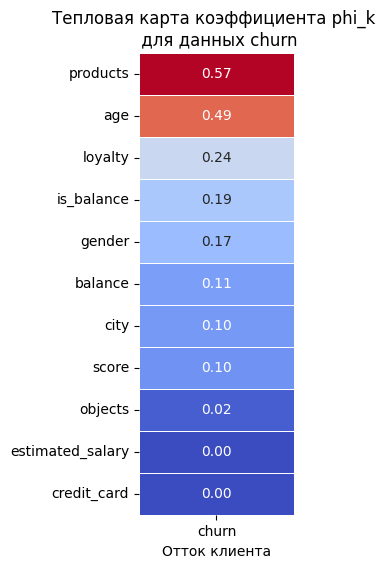

In [ ]:
plt.figure(figsize=(2, 6))
sns.heatmap(churn_corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar=False)
plt.title('Связь признаков с оттоком (phi_k)')
plt.xlabel('')
plt.show()

Сильнее всего с оттоком связаны **количество продуктов** (~0.57), **возраст** (~0.49) и **активность клиента** (~0.24). Далее идут `is_balance` (~0.19) и пол (~0.17). Доход, кредитная карта и количество объектов с оттоком практически не связаны.

`phi_k` показывает силу связи, но не её направление. Направление смотрю по сегментам.

### 3.5. Отток по сегментам

Для сравнения сегментов пишу функцию: столбчатая диаграмма с долей оттока в каждой группе и линией среднего по всем клиентам — сразу видно, какие группы выше нормы.

In [ ]:
def plot_bar_plot(df, groupby, value, aggfunc, title, ylabel, xlabel):
    '''
    Столбчатая диаграмма метрики по группам с линией общего значения.

    df      — датафрейм;
    groupby — столбец для группировки;
    value   — столбец с метрикой;
    aggfunc — функция агрегации ('mean', 'sum', ...);
    title, ylabel, xlabel — подписи графика.
    '''
    grouped = df.groupby(groupby).agg({value: aggfunc})
    grouped.plot(kind='bar', title=title, legend=True,
                 ylabel=ylabel, xlabel=xlabel, rot=0, figsize=(7, 3))

    overall = df[value].agg(aggfunc)
    plt.axhline(overall, color='red', linestyle='--', linewidth=1,
                label=f'Все клиенты: {overall:.3f}')

    plt.grid()
    plt.legend()
    plt.show()

In [ ]:
plot_bar_plot(df, groupby='city', value='churn', aggfunc='mean',
              title='Доля ушедших клиентов по городам',
              ylabel='Доля ушедших', xlabel='Город')

В Ростове Великом доля оттока ~32% — вдвое выше, чем в Ярославле и Рыбинске (~16%). Это самый заметный региональный сигнал: стоит выяснить, что там происходит (конкуренты, качество обслуживания в отделениях, условия продуктов).

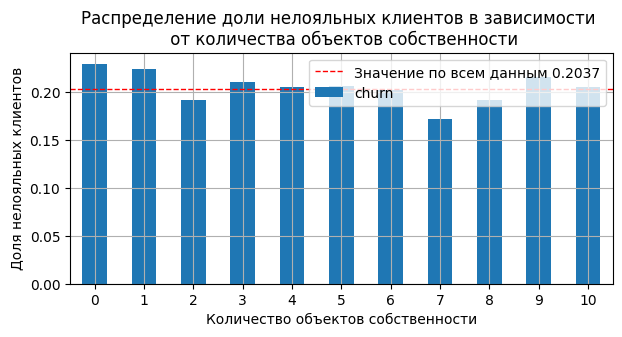

In [ ]:
plot_bar_plot(df, groupby='objects', value='churn', aggfunc='mean',
              title='Доля ушедших клиентов по количеству объектов собственности',
              ylabel='Доля ушедших', xlabel='Количество объектов собственности')

Чёткой зависимости от количества объектов нет — все группы около среднего.

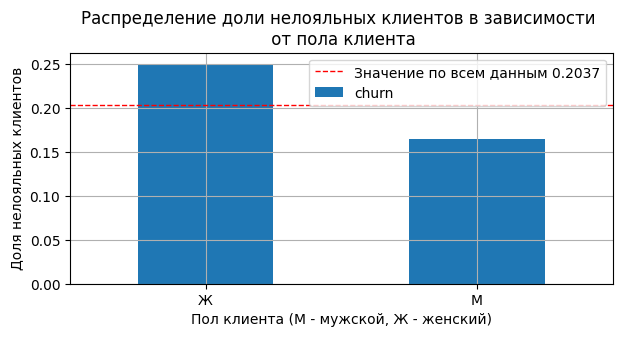

In [ ]:
plot_bar_plot(df, groupby='gender', value='churn', aggfunc='mean',
              title='Доля ушедших клиентов по полу',
              ylabel='Доля ушедших', xlabel='Пол (М — мужской, Ж — женский)')

Среди женщин отток выше, чем среди мужчин: ~25% против ~16%.

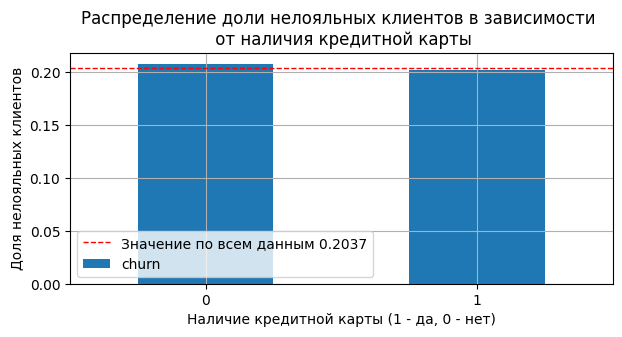

In [ ]:
plot_bar_plot(df, groupby='credit_card', value='churn', aggfunc='mean',
              title='Доля ушедших клиентов по наличию кредитной карты',
              ylabel='Доля ушедших', xlabel='Кредитная карта (1 — есть, 0 — нет)')

Наличие кредитной карты на отток практически не влияет.

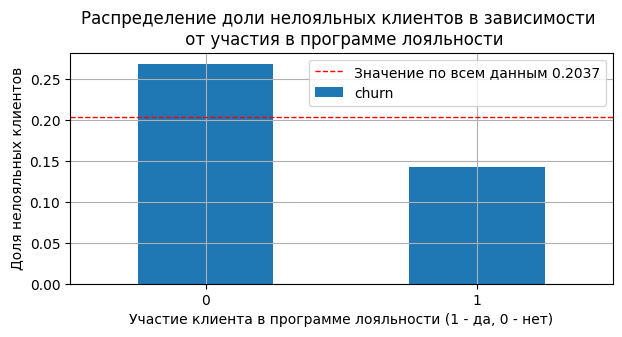

In [ ]:
plot_bar_plot(df, groupby='loyalty', value='churn', aggfunc='mean',
              title='Доля ушедших клиентов по активности',
              ylabel='Доля ушедших', xlabel='Активный клиент (1 — да, 0 — нет)')

Неактивные клиенты уходят почти вдвое чаще: ~27% против ~14%.

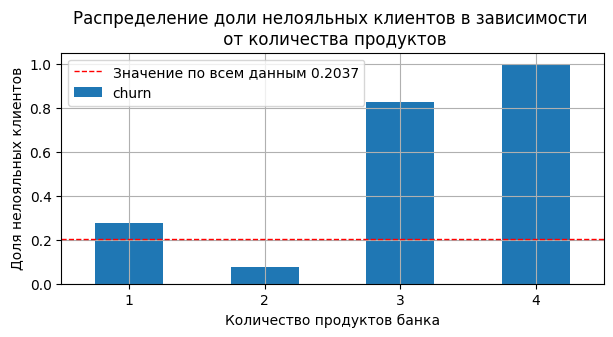

In [ ]:
plot_bar_plot(df, groupby='products', value='churn', aggfunc='mean',
              title='Доля ушедших клиентов по количеству продуктов',
              ylabel='Доля ушедших', xlabel='Количество продуктов банка')

Клиенты с одним продуктом уходят в ~3 раза чаще, чем с двумя: ~27% против ~8%. Группы с 3–4 продуктами слишком малы (326 клиентов), чтобы делать по ним выводы.

In [ ]:
plot_bar_plot(df, groupby='is_balance', value='churn', aggfunc='mean',
              title='Доля ушедших клиентов по наличию баланса',
              ylabel='Доля ушедших', xlabel='Баланс указан (1 — да, 0 — нет)')

Клиенты без указанного баланса уходят реже: ~14% против ~24%.

#### Непрерывные признаки в разрезе оттока

Ушедших клиентов в 4 раза меньше, чем оставшихся, поэтому гистограммы строю с нормировкой (`density=True`) — так формы распределений можно сравнивать напрямую. Ширину корзин задаю одинаковой для обеих групп.

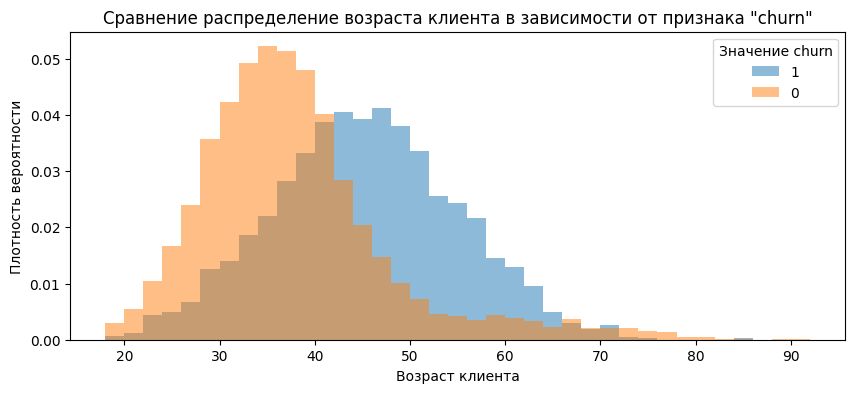

In [ ]:
plt.figure(figsize=(10, 4))
bins = range(df['age'].min(), df['age'].max() + 1, 2)

for value in sorted(df['churn'].unique()):
    df.loc[df['churn'] == value, 'age'].plot(
        kind='hist', density=True, bins=bins, alpha=0.5,
        label=f'churn = {value}', legend=True
    )

plt.title('Распределение возраста: ушедшие и оставшиеся клиенты')
plt.xlabel('Возраст')
plt.ylabel('Плотность')
plt.legend()
plt.show()

In [ ]:
df.groupby('churn')['age'].agg(['mean', 'median'])

Распределение возраста ушедших клиентов заметно сдвинуто вправо: медиана 45 лет против 36 у оставшихся. Ядро оставшихся — 30–40 лет, ушедших — 40–50. Это согласуется с высоким `phi_k` для возраста (~0.49).

Чтобы не дублировать код для остальных признаков, выношу построение в функцию с опциональной линией KDE:

In [ ]:
def plot_hist(df, column, groupby, title, xlabel, ylabel, binwidth, kde=False):
    '''
    Нормированные гистограммы признака column для каждой группы groupby.

    binwidth — ширина корзины;
    kde      — добавить сглаженную оценку плотности (KDE).
    '''
    plt.figure(figsize=(7, 3))
    min_value = int(df[column].min())
    max_value = int(df[column].max()) + 1
    bins = range(min_value, max_value + binwidth, binwidth)

    for value in sorted(df[groupby].unique()):
        data = df.loc[df[groupby] == value, column]
        data.plot(kind='hist', density=True, bins=bins, alpha=0.5,
                  label=f'{groupby} = {value}')
        if kde:
            data.plot(kind='kde', label=f'KDE {groupby} = {value}')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(min_value, max_value)
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
plot_hist(df, column='balance', groupby='churn', binwidth=5000, kde=True,
          title='Баланс: ушедшие и оставшиеся клиенты',
          xlabel='Баланс', ylabel='Плотность')

In [ ]:
plot_hist(df, column='estimated_salary', groupby='churn', binwidth=5000, kde=True,
          title='Оценочный доход: ушедшие и оставшиеся клиенты',
          xlabel='Оценочный доход', ylabel='Плотность')

Распределения баланса и дохода у ушедших и оставшихся практически совпадают — сами по себе эти признаки отток не объясняют.

In [ ]:
plot_hist(df, column='score', groupby='churn', binwidth=10, kde=True,
          title='Кредитный скоринг: ушедшие и оставшиеся клиенты',
          xlabel='Кредитный скоринг', ylabel='Плотность')

Скоринг на отток почти не влияет: у ушедших немного больше клиентов в районе 600, у оставшихся — в районе 700, но средние близки.

#### Возраст × баланс

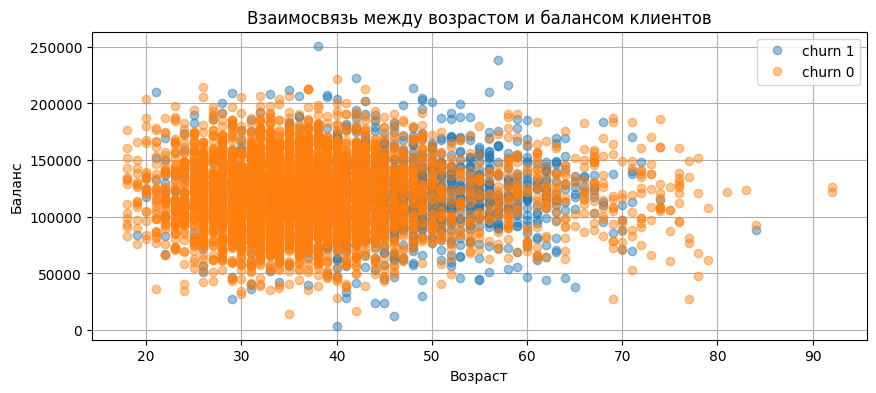

In [ ]:
plt.figure(figsize=(10, 4))

for value in sorted(df['churn'].unique()):
    plot_data = df.loc[df['churn'] == value]
    plt.plot(plot_data['age'], plot_data['balance'],
             marker='o', linestyle='', alpha=0.45, label=f'churn = {value}')

plt.title('Возраст и баланс клиентов')
plt.xlabel('Возраст')
plt.ylabel('Баланс')
plt.legend()
plt.grid()
plt.show()

Ушедшие клиенты концентрируются в возрасте 40–60 лет на всём диапазоне баланса, а явной зависимости оттока от баланса диаграмма не показывает.

---

## 4. Выводы и рекомендации

Проанализированы данные 10 000 клиентов банка «Метанпром» из Ярославля, Ростова Великого и Рыбинска. Общий отток — ~20%.

### Что связано с оттоком

| Фактор | Группа риска | Отток в группе | Сравнение |
|---|---|---|---|
| Количество продуктов | 1 продукт | ~27% | ~8% у клиентов с 2 продуктами |
| Возраст | 40–50 лет | медиана 45 лет у ушедших | 36 лет у оставшихся |
| Город | Ростов Великий | ~32% | ~16% в Ярославле и Рыбинске |
| Активность | неактивные | ~27% | ~14% у активных |
| Пол | женщины | ~25% | ~16% у мужчин |
| Баланс | баланс указан | ~24% | ~14% без баланса |

Баланс, доход, кредитный скоринг, наличие кредитной карты и количество объектов собственности на отток практически не влияют.

**Портрет уходящего клиента:** клиент 40–50 лет с одним продуктом банка, неактивный, чаще из Ростова Великого.

### Рекомендации

1. **Кросс-продажа второго продукта** клиентам с одним продуктом — это самая многочисленная группа риска, а при двух продуктах отток падает в ~3 раза.
2. **Удерживающие предложения для клиентов 40–50 лет**: условия по вкладам и кредитам, персональное обслуживание.
3. **Разобраться с Ростовом Великим**: отток там вдвое выше — проверить работу отделений, условия продуктов и активность конкурентов.
4. **Реактивация неактивных клиентов** через программу лояльности.
5. **Следующий шаг** — модель оттока (например, логистическая регрессия или градиентный бустинг), чтобы оценивать риск ухода для каждого клиента и вовремя запускать удержание.